In [1]:
import os
import re
import cv2
import glob
import json
import random
import shutil
import tempfile
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNeXt50_32X4D_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
SPLIT_DIR = r"D:\Courses\DEPI\project\DeepFake\splits_v6"
CHECKPOINT_DIR = r"D:\Courses\DEPI\project\DeepFake\checkpoints_v6"
RESULTS_DIR = r"D:\Courses\DEPI\project\DeepFake\results_v8"

os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SIZE = 224
SEQUENCE_LENGTH = 32
BATCH_SIZE = 2
NUM_WORKERS = 0

BEST_MODEL_FILENAME = "best_model_v8.pth"

# Inference upgrades
USE_FACE_CROP = True
FACE_EXPAND_RATIO = 0.25
MULTI_CLIP_INFERENCE = True
NUM_CLIPS = 3

# OpenCV DNN face detector (Caffe SSD)
FACE_DETECTOR_DIR = r"D:\Courses\DEPI\project\DeepFake\models\face_detector"
DNN_FACE_MODEL_PATH = os.path.join(FACE_DETECTOR_DIR, "res10_300x300_ssd_iter_140000_fp16.caffemodel")
DNN_FACE_CONFIG_PATH = os.path.join(FACE_DETECTOR_DIR, "deploy.prototxt")

# Auto-download settings
AUTO_DOWNLOAD_DNN = True
FORCE_REDOWNLOAD_DNN = False


In [3]:
import os
import urllib.request

FACE_DETECTOR_DIR = r"D:\Courses\DEPI\project\DeepFake\models\face_detector"
os.makedirs(FACE_DETECTOR_DIR, exist_ok=True)

DNN_FACE_CONFIG_PATH = os.path.join(FACE_DETECTOR_DIR, "deploy.prototxt")
DNN_FACE_MODEL_PATH = os.path.join(FACE_DETECTOR_DIR, "res10_300x300_ssd_iter_140000.caffemodel")

CONFIG_URL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
MODEL_URL  = "https://raw.githubusercontent.com/sr6033/face-detection-with-OpenCV-and-DNN/master/res10_300x300_ssd_iter_140000.caffemodel"

def download_file(url, dst):
    if os.path.exists(dst):
        print("Already exists:", dst)
        return
    print("Downloading:", url)
    urllib.request.urlretrieve(url, dst)
    print("Saved to    :", dst)

download_file(CONFIG_URL, DNN_FACE_CONFIG_PATH)
download_file(MODEL_URL, DNN_FACE_MODEL_PATH)

print("\nDone.")
print("Config:", DNN_FACE_CONFIG_PATH)
print("Model :", DNN_FACE_MODEL_PATH)

Downloading: https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Saved to    : D:\Courses\DEPI\project\DeepFake\models\face_detector\deploy.prototxt
Downloading: https://raw.githubusercontent.com/sr6033/face-detection-with-OpenCV-and-DNN/master/res10_300x300_ssd_iter_140000.caffemodel
Saved to    : D:\Courses\DEPI\project\DeepFake\models\face_detector\res10_300x300_ssd_iter_140000.caffemodel

Done.
Config: D:\Courses\DEPI\project\DeepFake\models\face_detector\deploy.prototxt
Model : D:\Courses\DEPI\project\DeepFake\models\face_detector\res10_300x300_ssd_iter_140000.caffemodel


In [4]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

def natural_key(text):
    return [int(tok) if tok.isdigit() else tok.lower() for tok in re.split(r"(\d+)", str(text))]

def get_frame_paths(folder_path: str):
    valid_exts = {".jpg", ".jpeg", ".png"}
    frame_paths = []

    for name in os.listdir(folder_path):
        full_path = os.path.join(folder_path, name)
        if os.path.isfile(full_path):
            ext = os.path.splitext(name)[1].lower()
            if ext in valid_exts:
                frame_paths.append(full_path)

    return sorted(frame_paths, key=natural_key)

class FrameFolderDataset(Dataset):
    def __init__(self, df, sequence_length=32, transform=None):
        self.df = df.reset_index(drop=True)
        self.sequence_length = sequence_length
        self.transform = transform
        self.frame_cache = {
            row["folder_path"]: get_frame_paths(row["folder_path"])
            for _, row in self.df.iterrows()
        }

    def __len__(self):
        return len(self.df)

    def _select_uniform(self, frame_paths):
        n = len(frame_paths)
        if n == 0:
            raise ValueError("No frames found.")

        if n < self.sequence_length:
            selected = list(frame_paths)
            while len(selected) < self.sequence_length:
                selected.append(selected[-1])
            return selected

        idxs = np.linspace(0, n - 1, self.sequence_length, dtype=int)
        return [frame_paths[i] for i in idxs]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        folder_path = row["folder_path"]
        label = int(row["label"])

        frame_paths = self.frame_cache[folder_path]
        selected_paths = self._select_uniform(frame_paths)

        frames = []
        for fp in selected_paths:
            with Image.open(fp) as img:
                img = img.convert("RGB")
                img = self.transform(img)
                frames.append(img)

        frames = torch.stack(frames)
        return frames, torch.tensor(label, dtype=torch.long), folder_path
class FastFaceDetector:
    def __init__(self):
        haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        self.detector = cv2.CascadeClassifier(haar_path)
        if self.detector.empty():
            raise ValueError(f"Could not load Haar cascade from: {haar_path}")

    def detect_largest_face(self, frame_bgr):
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        faces = self.detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
        if len(faces) == 0:
            return None
        faces = sorted(faces, key=lambda b: b[2] * b[3], reverse=True)
        x, y, w, h = faces[0]
        return (int(x), int(y), int(w), int(h))

FACE_DETECTOR = FastFaceDetector() if USE_FACE_CROP else None

def crop_face_from_pil(img, detector=None, expand_ratio=0.25, fallback_full_frame=True):
    if detector is None:
        return img
    frame_bgr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    box = detector.detect_largest_face(frame_bgr)
    if box is None:
        return img if fallback_full_frame else None

    h, w = frame_bgr.shape[:2]
    x, y, bw, bh = box
    cx = x + bw / 2.0
    cy = y + bh / 2.0
    bw *= (1.0 + expand_ratio)
    bh *= (1.0 + expand_ratio)
    x1 = max(0, int(cx - bw / 2.0))
    y1 = max(0, int(cy - bh / 2.0))
    x2 = min(w, int(cx + bw / 2.0))
    y2 = min(h, int(cy + bh / 2.0))
    if x2 <= x1 or y2 <= y1:
        return img if fallback_full_frame else None
    cropped = frame_bgr[y1:y2, x1:x2]
    cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    return Image.fromarray(cropped)


In [5]:
class TemporalAttentionPooling(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(in_dim, in_dim // 2),
            nn.Tanh(),
            nn.Linear(in_dim // 2, 1)
        )

    def forward(self, x):
        attn_logits = self.score(x).squeeze(-1)
        attn_weights = torch.softmax(attn_logits, dim=1)
        pooled = torch.sum(x * attn_weights.unsqueeze(-1), dim=1)
        return pooled, attn_weights

class DeepFakeModel(nn.Module):
    def __init__(self, num_classes=2, hidden_dim=256, lstm_layers=1, dropout=0.4):
        super().__init__()

        backbone = models.resnext50_32x4d(weights=ResNeXt50_32X4D_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.feature_dim = 2048

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if lstm_layers == 1 else dropout
        )

        temporal_dim = hidden_dim * 2
        self.temporal_attention = TemporalAttentionPooling(temporal_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(temporal_dim, num_classes)

    def forward(self, x, return_attention=False):
        batch_size, seq_len, c, h, w = x.shape
        x = x.view(batch_size * seq_len, c, h, w)

        feats = self.backbone(x)
        feats = self.avgpool(feats).flatten(1)
        feats = feats.view(batch_size, seq_len, self.feature_dim)

        lstm_out, _ = self.lstm(feats)
        temporal_feat, attn_weights = self.temporal_attention(lstm_out)
        out = self.dropout(temporal_feat)
        out = self.fc(out)

        if return_attention:
            return out, attn_weights
        return out

def load_best_model(model, checkpoint_dir, filename, device):
    model_path = os.path.join(checkpoint_dir, filename)
    assert os.path.exists(model_path), f"Best model not found: {model_path}"

    ckpt = torch.load(model_path, map_location=device)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
        metadata = {k: v for k, v in ckpt.items() if k != "model_state_dict"}
    else:
        state_dict = ckpt
        metadata = {}

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    return model_path, metadata

model = DeepFakeModel().to(device)
loaded_model_path, loaded_metadata = load_best_model(
    model=model,
    checkpoint_dir=CHECKPOINT_DIR,
    filename=BEST_MODEL_FILENAME,
    device=device
)

print("Best model loaded successfully.")
print("Model path:", loaded_model_path)
if loaded_metadata:
    print("Checkpoint metadata keys:", list(loaded_metadata.keys()))


Best model loaded successfully.
Model path: D:\Courses\DEPI\project\DeepFake\checkpoints_v6\best_model_v8.pth
Checkpoint metadata keys: ['best_threshold', 'best_selection_score', 'epoch']


In [6]:
import os
import pandas as pd

SPLIT_DIR = r"D:\Courses\DEPI\project\DeepFake\splits_v6"

possible_names = [
    ("train.csv", "val.csv", "test.csv"),
    ("train_split.csv", "val_split.csv", "test_split.csv"),
    ("train_df.csv", "val_df.csv", "test_df.csv"),
]

selected = None
for names in possible_names:
    t, v, te = [os.path.join(SPLIT_DIR, n) for n in names]
    if os.path.exists(t) and os.path.exists(v) and os.path.exists(te):
        selected = (t, v, te)
        break

if selected is None:
    raise FileNotFoundError(f"Could not find split CSV files inside: {SPLIT_DIR}")

train_csv, val_csv, test_csv = selected

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Loaded split files:")
print("Train:", train_csv, train_df.shape)
print("Val  :", val_csv, val_df.shape)
print("Test :", test_csv, test_df.shape)

Loaded split files:
Train: D:\Courses\DEPI\project\DeepFake\splits_v6\train_df.csv (2429, 11)
Val  : D:\Courses\DEPI\project\DeepFake\splits_v6\val_df.csv (521, 11)
Test : D:\Courses\DEPI\project\DeepFake\splits_v6\test_df.csv (521, 11)


In [7]:
val_dataset = FrameFolderDataset(val_df, sequence_length=SEQUENCE_LENGTH, transform=val_transforms)
test_dataset = FrameFolderDataset(test_df, sequence_length=SEQUENCE_LENGTH, transform=val_transforms)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Val batches :", len(val_loader))
print("Test batches:", len(test_loader))

Val batches : 261
Test batches: 261


In [8]:
def collect_predictions(model, loader, device):
    all_labels = []
    all_probs = []
    all_rows = []

    model.eval()
    with torch.no_grad():
        for frames, labels, folder_paths in loader:
            frames = frames.to(device, non_blocking=True)
            outputs = model(frames)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()

            all_labels.extend(labels.numpy().tolist())
            all_probs.extend(probs.tolist())

            for i in range(len(folder_paths)):
                all_rows.append({
                    "folder_path": folder_paths[i],
                    "true_label": int(labels[i].item()),
                    "fake_probability": float(probs[i, 0]),
                    "real_probability": float(probs[i, 1]),
                })

    return all_labels, np.array(all_probs, dtype=np.float32), all_rows

def evaluate_thresholds(labels, probs, threshold_candidates):
    rows = []
    labels_np = np.asarray(labels)
    real_probs = probs[:, 1]

    for thr in threshold_candidates:
        preds = (real_probs >= thr).astype(np.int64)

        rows.append({
            "threshold": float(thr),
            "accuracy": float((preds == labels_np).mean()),
            "macro_f1": float(f1_score(labels_np, preds, average="macro", zero_division=0)),
            "fake_f1": float(f1_score(labels_np, preds, pos_label=0, zero_division=0)),
            "real_f1": float(f1_score(labels_np, preds, pos_label=1, zero_division=0)),
            "fake_precision": float(precision_score(labels_np, preds, pos_label=0, zero_division=0)),
            "fake_recall": float(recall_score(labels_np, preds, pos_label=0, zero_division=0)),
            "real_precision": float(precision_score(labels_np, preds, pos_label=1, zero_division=0)),
            "real_recall": float(recall_score(labels_np, preds, pos_label=1, zero_division=0)),
            "real_false_negative_rate": float(((preds == 0) & (labels_np == 1)).sum() / max((labels_np == 1).sum(), 1))
        })

    return pd.DataFrame(rows)

val_labels, val_probs, val_rows = collect_predictions(model, val_loader, device)

# Match Notebook 2 tuning range more closely.
threshold_candidates = np.round(np.arange(0.35, 0.66, 0.01), 2)
threshold_table = evaluate_thresholds(val_labels, val_probs, threshold_candidates)

best_macro_row = threshold_table.sort_values(
    ["macro_f1", "real_f1", "threshold"],
    ascending=[False, False, False]
).iloc[0]

best_real_safe_row = threshold_table.sort_values(
    ["real_f1", "real_precision", "macro_f1", "threshold"],
    ascending=[False, False, False, False]
).iloc[0]

best_threshold = float(best_macro_row["threshold"])
real_safe_threshold = float(best_real_safe_row["threshold"])

print("Selected thresholds:")
print(" - best_threshold      :", best_threshold)
print(" - real_safe_threshold :", real_safe_threshold)
print()
print("Top thresholds by Macro F1:")
display(threshold_table.sort_values(["macro_f1", "real_f1"], ascending=False).head(10))

Selected thresholds:
 - best_threshold      : 0.47
 - real_safe_threshold : 0.47

Top thresholds by Macro F1:


,threshold,accuracy,macro_f1,fake_f1,real_f1,fake_precision,fake_recall,real_precision,real_recall,real_false_negative_rate
7,0.42,0.950096,0.949754,0.953901,0.945607,0.957295,0.950530,0.941667,0.94958,0.05042
8,0.43,0.950096,0.949754,0.953901,0.945607,0.957295,0.950530,0.941667,0.94958,0.05042
9,0.44,0.950096,0.949754,0.953901,0.945607,0.957295,0.950530,0.941667,0.94958,0.05042
10,0.45,0.950096,0.949754,0.953901,0.945607,0.957295,0.950530,0.941667,0.94958,0.05042
11,0.46,0.950096,0.949754,0.953901,0.945607,0.957295,0.950530,0.941667,0.94958,0.05042
12,0.47,0.950096,0.949754,0.953901,0.945607,0.957295,0.950530,0.941667,0.94958,0.05042
4,0.39,0.948177,0.947838,0.952043,0.943633,0.957143,0.946996,0.937759,0.94958,0.05042
5,0.40,0.948177,0.947838,0.952043,0.943633,0.957143,0.946996,0.937759,0.94958,0.05042
6,0.41,0.948177,0.947838,0.952043,0.943633,0.957143,0.946996,0.937759,0.94958,0.05042
3,0.38,0.946257,0.945922,0.950178,0.941667,0.956989,0.943463,0.933884,0.94958,0.05042


In [9]:
# Recommended usage:
# - best_threshold      -> best balanced test-set evaluation
# - real_safe_threshold -> more conservative on external real-world videos
INFERENCE_THRESHOLD = best_threshold

test_labels, test_probs, test_rows = collect_predictions(model, test_loader, device)
test_preds = (test_probs[:, 1] >= INFERENCE_THRESHOLD).astype(np.int64)

test_acc = float((test_preds == np.array(test_labels)).mean())
test_fake_f1 = float(f1_score(test_labels, test_preds, pos_label=0, zero_division=0))
test_real_f1 = float(f1_score(test_labels, test_preds, pos_label=1, zero_division=0))
test_macro_f1 = float(f1_score(test_labels, test_preds, average="macro", zero_division=0))

test_fake_precision = float(precision_score(test_labels, test_preds, pos_label=0, zero_division=0))
test_fake_recall = float(recall_score(test_labels, test_preds, pos_label=0, zero_division=0))

test_real_precision = float(precision_score(test_labels, test_preds, pos_label=1, zero_division=0))
test_real_recall = float(recall_score(test_labels, test_preds, pos_label=1, zero_division=0))

print("Test evaluation")
print(f"Threshold used      : {INFERENCE_THRESHOLD:.2f}")
print(f"Accuracy            : {test_acc:.4f}")
print(f"Macro F1            : {test_macro_f1:.4f}")
print(f"Fake F1             : {test_fake_f1:.4f}")
print(f"Real F1             : {test_real_f1:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=["Fake", "Real"], zero_division=0))

Test evaluation
Threshold used      : 0.47
Accuracy            : 0.9482
Macro F1            : 0.9477
Fake F1             : 0.9529
Real F1             : 0.9424

              precision    recall  f1-score   support

        Fake       0.94      0.96      0.95       284
        Real       0.95      0.93      0.94       237

    accuracy                           0.95       521
   macro avg       0.95      0.95      0.95       521
weighted avg       0.95      0.95      0.95       521



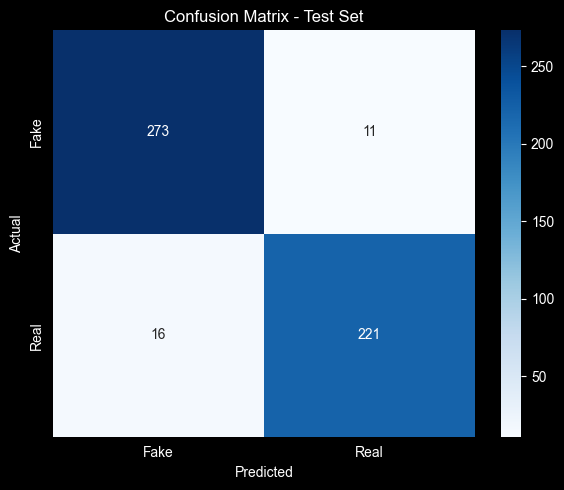

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

In [11]:
results_df = pd.DataFrame(test_rows)
results_df["pred_label"] = test_preds
results_df["pred_class_name"] = results_df["pred_label"].map({0: "Fake", 1: "Real"})
results_df["true_class_name"] = results_df["true_label"].map({0: "Fake", 1: "Real"})
results_df["used_threshold"] = INFERENCE_THRESHOLD

results_csv_path = os.path.join(RESULTS_DIR, "test_predictions_v6.csv")
results_df.to_csv(results_csv_path, index=False)

hard_false_negatives = results_df[
    (results_df["true_label"] == 0) & (results_df["pred_label"] == 1)
].sort_values("real_probability", ascending=False)

hard_false_positives = results_df[
    (results_df["true_label"] == 1) & (results_df["pred_label"] == 0)
].sort_values("fake_probability", ascending=False)

hard_fn_path = os.path.join(RESULTS_DIR, "hard_false_negatives_v6.csv")
hard_fp_path = os.path.join(RESULTS_DIR, "hard_false_positives_v6.csv")

hard_false_negatives.to_csv(hard_fn_path, index=False)
hard_false_positives.to_csv(hard_fp_path, index=False)

summary = {
    "best_model_path": loaded_model_path,
    "best_threshold": best_threshold,
    "real_safe_threshold": real_safe_threshold,
    "INFERENCE_THRESHOLD": INFERENCE_THRESHOLD,
    "test_accuracy": test_acc,
    "test_macro_f1": test_macro_f1,
    "test_fake_f1": test_fake_f1,
    "test_real_f1": test_real_f1,
    "test_fake_precision": test_fake_precision,
    "test_fake_recall": test_fake_recall,
    "test_real_precision": test_real_precision,
    "test_real_recall": test_real_recall,
    "classification_report": classification_report(
        test_labels,
        test_preds,
        target_names=["Fake", "Real"],
        output_dict=True,
        zero_division=0
    )
}

summary_json_path = os.path.join(RESULTS_DIR, "evaluation_summary_v6.json")
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4)

print("Saved:")
print(" -", results_csv_path)
print(" -", hard_fn_path)
print(" -", hard_fp_path)
print(" -", summary_json_path)

Saved:
 - D:\Courses\DEPI\project\DeepFake\results_v8\test_predictions_v6.csv
 - D:\Courses\DEPI\project\DeepFake\results_v8\hard_false_negatives_v6.csv
 - D:\Courses\DEPI\project\DeepFake\results_v8\hard_false_positives_v6.csv
 - D:\Courses\DEPI\project\DeepFake\results_v8\evaluation_summary_v6.json


In [12]:
def _prepare_tensor_from_frame_paths(frame_paths, transform, sequence_length, device):
    if len(frame_paths) == 0:
        raise ValueError("No frames found.")

    if len(frame_paths) < sequence_length:
        selected = list(frame_paths)
        while len(selected) < sequence_length:
            selected.append(selected[-1])
    else:
        idxs = np.linspace(0, len(frame_paths) - 1, sequence_length, dtype=int)
        selected = [frame_paths[i] for i in idxs]

    frames = []
    for fp in selected:
        with Image.open(fp) as img:
            img = img.convert("RGB")
            img = transform(img)
            frames.append(img)

    return torch.stack(frames).unsqueeze(0).to(device), selected

def predict_video_from_processed_frames(
    folder_path,
    model,
    transform,
    sequence_length=32,
    threshold=None,
    device="cuda"
):
    if threshold is None:
        threshold = best_threshold

    frame_paths = get_frame_paths(folder_path)
    tensor, selected = _prepare_tensor_from_frame_paths(frame_paths, transform, sequence_length, device)

    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1).squeeze(0).cpu().numpy()

    fake_prob = float(probs[0])
    real_prob = float(probs[1])
    pred_label = "Real" if real_prob >= threshold else "Fake"

    return {
        "input_type": "processed_frames_folder",
        "folder_path": folder_path,
        "predicted_label": pred_label,
        "fake_probability": fake_prob,
        "real_probability": real_prob,
        "threshold_used": threshold,
        "sampled_frames": len(selected),
        "total_frames_found": len(frame_paths)
    }

def _uniform_video_indices(total_frames, num_frames):
    if total_frames <= 0:
        return []
    if total_frames <= num_frames:
        idxs = list(range(total_frames))
        while len(idxs) < num_frames:
            idxs.append(idxs[-1])
        return idxs
    return np.linspace(0, total_frames - 1, num_frames, dtype=int).tolist()

class FaceDetectorWrapper:
    def __init__(self, backend="mediapipe", min_confidence=0.5):
        self.backend = None
        self.detector = None

        if backend == "mediapipe":
            try:
                import mediapipe as mp
                self.mp = mp
                self.detector = mp.solutions.face_detection.FaceDetection(
                    model_selection=1,
                    min_detection_confidence=min_confidence
                )
                self.backend = "mediapipe"
            except Exception as e:
                warnings.warn(f"MediaPipe not available, falling back to Haar Cascade. Details: {e}")

        if self.backend is None:
            haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
            detector = cv2.CascadeClassifier(haar_path)
            if detector.empty():
                raise ValueError(f"Could not load Haar cascade from: {haar_path}")
            self.detector = detector
            self.backend = "haar"

    def detect_faces(self, frame_bgr):
        if self.backend == "mediapipe":
            h, w = frame_bgr.shape[:2]
            rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            result = self.detector.process(rgb)
            boxes = []

            if result.detections:
                for det in result.detections:
                    bbox = det.location_data.relative_bounding_box
                    x = max(0, int(bbox.xmin * w))
                    y = max(0, int(bbox.ymin * h))
                    bw = int(bbox.width * w)
                    bh = int(bbox.height * h)
                    if bw > 0 and bh > 0:
                        boxes.append((x, y, bw, bh))
            return boxes

        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        faces = self.detector.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(40, 40)
        )
        return list(faces)

def _crop_largest_face_bgr(frame_bgr, detector, expand_ratio=0.30):
    faces = detector.detect_faces(frame_bgr)
    if len(faces) == 0:
        return None

    faces = sorted(faces, key=lambda x: x[2] * x[3], reverse=True)
    x, y, w, h = faces[0]

    pad_w = int(w * expand_ratio)
    pad_h = int(h * expand_ratio)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(frame_bgr.shape[1], x + w + pad_w)
    y2 = min(frame_bgr.shape[0], y + h + pad_h)

    crop = frame_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return crop

def extract_video_to_temp_frames(
    video_path,
    output_dir,
    frames_to_extract=100,
    image_ext=".jpg",
    jpeg_quality=95,
    use_face_crop=True,
    expand_ratio=0.30,
    min_saved_frames=16,
    face_backend="mediapipe"
):
    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    detector = FaceDetectorWrapper(backend=face_backend) if use_face_crop else None
    used_face_backend = detector.backend if detector is not None else "none"

    if total_frames <= 0:
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)
        cap.release()

        if len(frames) == 0:
            raise ValueError(f"No frames could be read from video: {video_path}")

        idxs = _uniform_video_indices(len(frames), frames_to_extract)
        saved_paths = []
        for save_idx, frame_idx in enumerate(idxs):
            frame = frames[frame_idx]

            if use_face_crop:
                crop = _crop_largest_face_bgr(frame, detector, expand_ratio=expand_ratio)
                if crop is not None:
                    frame = crop

            save_path = os.path.join(output_dir, f"frame_{save_idx:04d}{image_ext}")
            cv2.imwrite(save_path, frame, [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality])
            saved_paths.append(save_path)
    else:
        idxs = set(_uniform_video_indices(total_frames, frames_to_extract))
        saved_paths = []
        frame_id = 0
        save_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_id in idxs:
                if use_face_crop:
                    crop = _crop_largest_face_bgr(frame, detector, expand_ratio=expand_ratio)
                    if crop is not None:
                        frame = crop

                save_path = os.path.join(output_dir, f"frame_{save_idx:04d}{image_ext}")
                cv2.imwrite(save_path, frame, [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality])
                saved_paths.append(save_path)
                save_idx += 1

            frame_id += 1

        cap.release()

    if len(saved_paths) < min_saved_frames:
        raise ValueError(
            f"Only {len(saved_paths)} frames were saved from video, "
            f"which is below min_saved_frames={min_saved_frames}."
        )

    return saved_paths, used_face_backend

def predict_raw_video(
    video_path,
    model,
    transform,
    sequence_length=32,
    threshold=None,
    device="cuda",
    frames_to_extract=100,
    keep_temp_frames=False,
    temp_root_dir=None,
    use_face_crop=True,
    expand_ratio=0.30,
    face_backend="dnn"
):
    if threshold is None:
        threshold = real_safe_threshold

    if temp_root_dir is None:
        temp_root_dir = tempfile.gettempdir()

    os.makedirs(temp_root_dir, exist_ok=True)
    temp_dir = tempfile.mkdtemp(prefix="deepfake_tmp_frames_", dir=temp_root_dir)

    try:
        saved_paths, used_face_backend = extract_video_to_temp_frames(
            video_path=video_path,
            output_dir=temp_dir,
            frames_to_extract=frames_to_extract,
            use_face_crop=use_face_crop,
            expand_ratio=expand_ratio,
            face_backend=face_backend
        )

        tensor, selected = _prepare_tensor_from_frame_paths(
            saved_paths, transform, sequence_length, device
        )

        model.eval()
        with torch.no_grad():
            outputs = model(tensor)
            probs = torch.softmax(outputs, dim=1).squeeze(0).cpu().numpy()

        fake_prob = float(probs[0])
        real_prob = float(probs[1])
        pred_label = "Real" if real_prob >= threshold else "Fake"

        result = {
            "input_type": "raw_video_via_temp_frames",
            "video_path": video_path,
            "predicted_label": pred_label,
            "fake_probability": fake_prob,
            "real_probability": real_prob,
            "threshold_used": threshold,
            "sampled_frames": len(selected),
            "total_frames_found": len(saved_paths),
            "face_crop_used": use_face_crop,
            "face_backend_used": used_face_backend,
            "temp_frames_dir": temp_dir if keep_temp_frames else "(deleted after run)"
        }

        if keep_temp_frames:
            result["extracted_temp_frames"] = len(saved_paths)
        return result

    finally:
        if not keep_temp_frames and os.path.exists(temp_dir):
            shutil.rmtree(temp_dir, ignore_errors=True)
def _prepare_tensor_from_frame_paths_multiclip(frame_paths, transform, sequence_length, device, num_clips=3):
    if len(frame_paths) == 0:
        raise ValueError("No frames found.")

    clips = []
    selected_groups = []

    total = len(frame_paths)
    if total < sequence_length:
        tensor, selected = _prepare_tensor_from_frame_paths(frame_paths, transform, sequence_length, device)
        return [tensor], [selected]

    max_start = max(total - sequence_length, 0)
    if num_clips <= 1 or max_start == 0:
        tensor, selected = _prepare_tensor_from_frame_paths(frame_paths, transform, sequence_length, device)
        return [tensor], [selected]

    starts = np.linspace(0, max_start, num_clips, dtype=int)
    for s in starts:
        clip_paths = frame_paths[s:s + sequence_length]
        if len(clip_paths) < sequence_length:
            clip_paths = list(clip_paths)
            while len(clip_paths) < sequence_length:
                clip_paths.append(clip_paths[-1])
        frames = []
        for fp in clip_paths:
            with Image.open(fp) as img:
                img = img.convert("RGB")
                if USE_FACE_CROP:
                    cropped = crop_face_from_pil(img, detector=FACE_DETECTOR, expand_ratio=FACE_EXPAND_RATIO, fallback_full_frame=True)
                    if cropped is not None:
                        img = cropped
                img = transform(img)
                frames.append(img)
        clips.append(torch.stack(frames).unsqueeze(0).to(device))
        selected_groups.append(clip_paths)

    return clips, selected_groups

def predict_video_from_processed_frames_multiclip(folder_path, model, transform, sequence_length=32, threshold=None, device="cuda", num_clips=3):
    if threshold is None:
        threshold = best_threshold

    frame_paths = get_frame_paths(folder_path)
    clips, selected_groups = _prepare_tensor_from_frame_paths_multiclip(frame_paths, transform, sequence_length, device, num_clips=num_clips)

    probs_list = []
    model.eval()
    with torch.no_grad():
        for clip in clips:
            outputs = model(clip)
            probs = torch.softmax(outputs, dim=1).squeeze(0).cpu().numpy()
            probs_list.append(probs)

    avg_probs = np.mean(np.stack(probs_list, axis=0), axis=0)
    fake_prob = float(avg_probs[0])
    real_prob = float(avg_probs[1])
    pred_label = "Real" if real_prob >= threshold else "Fake"

    return {
        "input_type": "processed_frames_folder_multiclip",
        "folder_path": folder_path,
        "predicted_label": pred_label,
        "fake_probability": fake_prob,
        "real_probability": real_prob,
        "threshold_used": threshold,
        "num_clips_used": len(clips),
        "sampled_frames_per_clip": sequence_length,
        "total_frames_found": len(frame_paths)
    }


In [13]:
print("DNN_FACE_CONFIG_PATH:", DNN_FACE_CONFIG_PATH)
print("DNN_FACE_MODEL_PATH :", DNN_FACE_MODEL_PATH)

import os
print("Config exists:", os.path.exists(DNN_FACE_CONFIG_PATH))
print("Model exists :", os.path.exists(DNN_FACE_MODEL_PATH))

DNN_FACE_CONFIG_PATH: D:\Courses\DEPI\project\DeepFake\models\face_detector\deploy.prototxt
DNN_FACE_MODEL_PATH : D:\Courses\DEPI\project\DeepFake\models\face_detector\res10_300x300_ssd_iter_140000.caffemodel
Config exists: True
Model exists : True


In [20]:
"""sample_folder = test_df.iloc[0]["folder_path"]

folder_result = predict_video_from_processed_frames(
    folder_path=sample_folder,
    model=model,
    transform=val_transforms,
    sequence_length=SEQUENCE_LENGTH,
    threshold=best_threshold,   # best balanced threshold on validation
    device=device
)

print("Processed-frames prediction:")
for key, value in folder_result.items():
    print(f"{key}: {value}")
"""

RAW_VIDEO_PATH = r"D:\Courses\DEPI\project\DeepFake\video\004_982.mp4"
RAW_VIDEO_FRAMES_TO_EXTRACT = 100
KEEP_TEMP_FRAMES = False

if os.path.exists(RAW_VIDEO_PATH):
    video_result = predict_raw_video(
        video_path=RAW_VIDEO_PATH,
        model=model,
        transform=val_transforms,
        sequence_length=SEQUENCE_LENGTH,
        threshold=real_safe_threshold,  # safer for external real-world videos
        device=device,
        frames_to_extract=RAW_VIDEO_FRAMES_TO_EXTRACT,
        keep_temp_frames=KEEP_TEMP_FRAMES,
        temp_root_dir=os.path.join(RESULTS_DIR, "temp_raw_video_frames"),
        use_face_crop=True,
        expand_ratio=0.30,
        face_backend="mediapipe"   # falls back to Haar automatically if MediaPipe is unavailable
    )

    print("\nRaw-video prediction:")
    for key, value in video_result.items():
        print(f"{key}: {value}")
else:
    print("\nRAW_VIDEO_PATH does not exist yet. Put your video path here and rerun this cell.")

C:\Users\Abdallah\AppData\Local\Temp\ipykernel_13200\1628958395.py:81: UserWarning: MediaPipe not available, falling back to Haar Cascade. Details: module 'mediapipe' has no attribute 'solutions'
  warnings.warn(f"MediaPipe not available, falling back to Haar Cascade. Details: {e}")



Raw-video prediction:
input_type: raw_video_via_temp_frames
video_path: D:\Courses\DEPI\project\DeepFake\video\004_982.mp4
predicted_label: Real
fake_probability: 0.052392564713954926
real_probability: 0.9476074576377869
threshold_used: 0.47
sampled_frames: 32
total_frames_found: 100
face_crop_used: True
face_backend_used: haar
temp_frames_dir: (deleted after run)


In [15]:
print("Notebook 3 ready.")
print(f"best_threshold        = {best_threshold:.2f}")
print(f"real_safe_threshold   = {real_safe_threshold:.2f}")
print(f"multi_clip_inference  = {MULTI_CLIP_INFERENCE}")
print(f"num_clips             = {NUM_CLIPS}")
print(f"use_face_crop         = {USE_FACE_CROP}")
print(f"results_dir           = {RESULTS_DIR}")


Notebook 3 ready.
best_threshold        = 0.47
real_safe_threshold   = 0.47
multi_clip_inference  = True
num_clips             = 3
use_face_crop         = True
results_dir           = D:\Courses\DEPI\project\DeepFake\results_v8


In [16]:

print("DNN face detector configuration:")
print("FACE_DETECTOR_DIR   :", FACE_DETECTOR_DIR)
print("DNN_FACE_MODEL_PATH :", DNN_FACE_MODEL_PATH)
print("DNN_FACE_CONFIG_PATH:", DNN_FACE_CONFIG_PATH)
print("Model exists        :", os.path.exists(DNN_FACE_MODEL_PATH))
print("Config exists       :", os.path.exists(DNN_FACE_CONFIG_PATH))
print("cv2 version         :", cv2.__version__)
print("FaceDetectorYN available:", hasattr(cv2, "FaceDetectorYN_create"))
print("\nIf DNN files exist, Notebook 3 will try DNN first, then Haar, then center-crop fallback.")


DNN face detector configuration:
FACE_DETECTOR_DIR   : D:\Courses\DEPI\project\DeepFake\models\face_detector
DNN_FACE_MODEL_PATH : D:\Courses\DEPI\project\DeepFake\models\face_detector\res10_300x300_ssd_iter_140000.caffemodel
DNN_FACE_CONFIG_PATH: D:\Courses\DEPI\project\DeepFake\models\face_detector\deploy.prototxt
Model exists        : True
Config exists       : True
cv2 version         : 4.13.0
FaceDetectorYN available: True

If DNN files exist, Notebook 3 will try DNN first, then Haar, then center-crop fallback.
